# Update 11 - Evidence grading for the measurement-chain budget

**Labels.**

- **quantified** - a number with a stated estimator and interval;
- **bounded** - a range from a justified assumption (spec, envelope), not a measured distribution;
- **unresolved** - not separable with this dataset; it carries an identifiability limitation, not a value.

**Outputs.** evidence_grading.json, evidence_grading.md, evidence_grading.png (candidate main-text figure), plus the §4 gate verdict.

In [1]:
# load the frozen artifacts

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ART = {
    'nb10_1overR'  : 'one_over_R_term.json',
    'nb07_blocks'  : 'paired_diff_block_sensitivity.json',
    'nb00_stats'   : 'campaign_statistics.json',
    'nb05_coverage': 'campaign_time_coverage.json',
    'nb09_envelope': 'joint_gain_offset_envelope.json',
}

def load(key):
    path = ART[key]
    if os.path.exists(path):
        with open(path) as fh:
            return json.load(fh), 'json'
    return None, 'MISSING'

nb10, s10 = load('nb10_1overR')
nb07, s07 = load('nb07_blocks')
stats, s_st = load('nb00_stats')
cov, s_cov = load('nb05_coverage')
env, s_env = load('nb09_envelope')

print('artifact provenance')
for k, s in (('nb10_1overR', s10), ('nb07_blocks', s07), ('nb00_stats', s_st),
             ('nb05_coverage', s_cov), ('nb09_envelope', s_env)):
    print(f'  {k:14s} {s:8s} {ART[k]}')

artifact provenance
  nb10_1overR    json     one_over_R_term.json
  nb07_blocks    json     paired_diff_block_sensitivity.json
  nb00_stats     json     campaign_statistics.json
  nb05_coverage  json     campaign_time_coverage.json
  nb09_envelope  json     joint_gain_offset_envelope.json


In [2]:
# joint gain-offset envelope.  If the production JSON snapshot is absent we fall back to the values documented in notebook 09 and say so.

ENV_DOC = {
    'T': dict(E=1.484e-9, u_syst=8.57e-10, sm=1.03e-7, g_max=1.1169,
              ch_only={'T': 0.757e-9, 'H': 0.630e-9, 'P': 0.008e-9}, b_vertex=-0.125),
    'H': dict(E=1.024e-9, u_syst=5.91e-10, sm=3.99e-9, g_max=1.3032,
              ch_only={'T': 0.293e-9, 'H': 0.659e-9, 'P': 0.000e-9}, b_vertex=-0.645),
    'P': dict(E=2.32e-10, u_syst=1.34e-10, sm=1.23e-8, g_max=1.0474,
              ch_only={'T': 0.038e-9, 'H': 0.087e-9, 'P': 0.097e-9}, b_vertex=-0.033),
}
DELTA_SPEC = {'T': 1.0, 'H': 4.0, 'P': 1.0}   # BME280 accuracy bound used for the envelope

def env_block(ch):
    if env is not None:
        w = env['worst_case'][ch]
        return dict(source='joint_gain_offset_envelope.json (production)',
                    E=w['E_sampled'], u_syst=w['u_syst_rectangular'],
                    sm=w['sm_single_branch'], g_max=env['envelope'][ch]['g_max'],
                    ch_only={c: env['channel_only'][c][ch] for c in ('T', 'H', 'P')},
                    b_vertex=env['envelope'][ch]['b_at_g_max'])
    return dict(source='notebook 09 (documented; production JSON snapshot pending)',
                **ENV_DOC[ch])

ENV = {ch: env_block(ch) for ch in ('T', 'H', 'P')}
print('step-6 envelope source:', ENV['H']['source'])
if env is not None:
    _sc = env.get('self_check', {})
    print(f"  snapshot      : {env['meta']['timestamp']}  "
          f"producer: {env['meta'].get('script', 'n/a')}")
    print(f"  self-check    : d_alpha_H rel. dev {_sc.get('d_alpha_H_rel_dev', float('nan')):.2e} "
          f"| E_sampled(H) {env['worst_case']['H']['E_sampled']:.3e} "
          f"| SM endpoint(H) {env['worst_case']['H']['sm_single_branch']:.3e}")
E_LIN_H = env['worst_case']['H']['E_linearised'] if env is not None else 0.915e-9
_TRI_H  = sum(ENV['H']['ch_only'].values())   # sampled triangle sum, nb 09 comp table
_COUPLING = 'exceeds' if ENV['H']['E'] > _TRI_H else 'does not exceed'

D_H          = 4.3334e-9      # archived full-resolution d(alpha_H) (step-1 gate)
U_STAT_SM    = 1.30e-9        # SM nominal paired bootstrap SE of the difference
SIGMA_EMP    = 1.8367e-7
SIGMA_MATHAR = 1.9304e-7
E_H, US_H    = ENV['H']['E'], ENV['H']['u_syst']

def se_from_ci(a):
    return (a['ci95_hi'] - a['ci95_lo']) / (2 * 1.96)

blk = {b['D_h']: b['aH'] for b in nb07['full_campaign']}
U_STAT_056 = se_from_ci(blk[0.56])
U_STAT_717 = se_from_ci(blk[7.17])
U_STAT_240 = se_from_ci(blk[24.0])
print(f'paired-difference SE: 0.56 h {U_STAT_056:.2e} | 7.17 h {U_STAT_717:.2e} | '
      f'24 h {U_STAT_240:.2e}')

n_indomain = sum(m['n_obs'] for m in cov['monthly'] if m['frac_T_in_Mathar_domain'] == 1.0)
lev        = nb10['leverage_per_ppm_e9']
levabs     = [abs(v) for v in lev.values()]
INJ_DD     = nb10['injection_monthly_epsR_e9'] * 1e-9
INJ_SB     = nb10['classification']['injection_e9']['shape_bounded_magnitude'] * 1e-9
CORR_TT    = nb10['corr_T_t']
print(f'in-domain rows: {n_indomain:,} | leverage {min(levabs):.2f}..{max(levabs):.2f}e-9 '
      f'per ppm | drift injection {INJ_DD*1e9:+.2f}..{INJ_SB*1e9:.1f}e-9 | '
      f'corr(T,t) = {CORR_TT:.3f}')

step-6 envelope source: joint_gain_offset_envelope.json (production)
  snapshot      : 2026-09-09T14:02:04Z  producer: 09_joint_gain_offset_envelope.ipynb
  self-check    : d_alpha_H rel. dev 1.23e-06 | E_sampled(H) 1.024e-09 | SM endpoint(H) 3.988e-09
paired-difference SE: 0.56 h 1.13e-09 | 7.17 h 3.69e-09 | 24 h 5.38e-09
in-domain rows: 12,134 | leverage 2.61..32.54e-9 per ppm | drift injection +4.37..13.4e-9 | corr(T,t) = 0.743


## Output A - absolute refractive index (scale and baseline)

What limits the absolute scale and the baseline? The unresolved 1.166e-6
offset dominates; the frequency reference and the wavelength conventions are
quantified and small. A component that matters here need not matter for the
coefficients.

In [3]:
COLS = ['source', 'label', 'qualifier', 'magnitude', 'temporal', 'evidence', 'effect']

def show(rows, title):
    print('=' * 100)
    print(title)
    print('=' * 100)
    for r in rows:
        print(f"\n[{r['label'].upper()}] {r['source']}")
        if r.get('qualifier'):
            print(f"    qualifier : {r['qualifier']}")
        print(f"    magnitude : {r['magnitude']}")
        print(f"    temporal  : {r['temporal']}")
        print(f"    evidence  : {r['evidence']}")
        print(f"    effect    : {r['effect']}")
    return pd.DataFrame(rows)[COLS]

rowsA = [
    dict(source='Anchoring / interferometric offset', label='unresolved',
         qualifier='hard boundary; not correctable with this dataset',
         magnitude='1.166e-6 (= 17.46 rad at 4.2 m; 4.16 rad/m)',
         temporal='static over the campaign; no independent monitor',
         evidence='nb 02; SM S1a; hard-boundary note',
         effect='limits the absolute scale and baseline and blocks any "Mathar absolutely '
                'correct" claim; absorbed by the fitted intercept, so it does not enter the '
                'coefficients'),
    dict(source='K convention (f_780/f_1762 vs documented 1762.17/780.24)', label='bounded',
         qualifier='convention / rounding, not a measurement',
         magnitude='dK/K = -5.17 ppm -> offset 5.2e-6, 4.4x the current 1.166e-6; 0.01 nm '
                   'rounding alone allows +/-6.4 ppm',
         temporal='static multiplicative',
         evidence='nb 10 sec. D; f_rb/f_1762 = 2.2584857037',
         effect='intercept only: dK/K from 1e-9 to 1e-7 leaves d(alpha_H)_read unchanged to '
                'four digits'),
    dict(source='780 nm frequency reference', label='quantified',
         qualifier='Rb D2 saturated-absorption lock',
         magnitude='dn = 1.0e-9 (dnu ~ 384 kHz at 384.230 THz)',
         temporal='static / long-term, wavemeter-monitored',
         evidence='SM S1a',
         effect='enters single-epoch n only; negligible for the coefficients'),
    dict(source='1762 nm quantum frequency reference', label='quantified',
         qualifier='',
         magnitude='dn < 1e-12',
         temporal='static',
         evidence='SM S1a',
         effect='negligible'),
    dict(source='Interferometer non-linearity', label='bounded',
         qualifier='declared negligible',
         magnitude='not quantified',
         temporal='static',
         evidence='SM S1a',
         effect='negligible'),
    dict(source='Residual scatter (incl. spatial/temporal mismatch)', label='quantified',
         qualifier='statistical; the decomposition is not source identification',
         magnitude='1.84e-7; of which measurement noise 1.78e-7 and model nonlinearity 4.4e-8',
         temporal='short-term scatter plus a slow component',
         evidence='SM S1a; nb 03',
         effect='sets single-epoch precision; the spatial/temporal mismatch inside it remains '
                'unresolved'),
    dict(source='Sensor-to-path spatial mismatch', label='unresolved',
         qualifier='possible contribution',
         magnitude='not separable; folded into the 1.84e-7 residual',
         temporal='short-term and slow',
         evidence='SM S1a',
         effect='may contribute to the coefficient difference; must not be quoted as resolved'),
    dict(source='Wavelength convention (Mathar 1.762 vs 1.762174 um; anchor 780.24 vs '
                    '780.246 nm)', label='quantified',
         qualifier='documentation item',
         magnitude='d(dH) = -0.21e-12 and +0.57e-12; anchor dn = -0.037 ppb',
         temporal='static',
         evidence='nb 10 sec. D',
         effect='<= 1e-12 on the coefficients: no recomputation needed, only explicit '
                'documentation'),
]

dfA = show(rowsA, 'Output A - absolute refractive index (scale and baseline)')

Output A - absolute refractive index (scale and baseline)

[UNRESOLVED] Anchoring / interferometric offset
    qualifier : hard boundary; not correctable with this dataset
    magnitude : 1.166e-6 (= 17.46 rad at 4.2 m; 4.16 rad/m)
    temporal  : static over the campaign; no independent monitor
    evidence  : nb 02; SM S1a; hard-boundary note
    effect    : limits the absolute scale and baseline and blocks any "Mathar absolutely correct" claim; absorbed by the fitted intercept, so it does not enter the coefficients

[BOUNDED] K convention (f_780/f_1762 vs documented 1762.17/780.24)
    qualifier : convention / rounding, not a measurement
    magnitude : dK/K = -5.17 ppm -> offset 5.2e-6, 4.4x the current 1.166e-6; 0.01 nm rounding alone allows +/-6.4 ppm
    temporal  : static multiplicative
    evidence  : nb 10 sec. D; f_rb/f_1762 = 2.2584857037
    effect    : intercept only: dK/K from 1e-9 to 1e-7 leaves d(alpha_H)_read unchanged to four digits

[QUANTIFIED] 780 nm frequency ref

## Output B - environmental coefficients and their difference from Mathar

Three independent constraints on the humidity difference: the statistical
uncertainty (block-length dependent), the consistent sensor-gain envelope
(bounded), and the unresolved slow 1/R(t) drift. Coverage and block length are
identifiability limits that no calibration quality can remove.

In [4]:
rowsB = [
    dict(source='Statistical uncertainty of the humidity difference', label='quantified',
         qualifier='conditional on block length; not robust across the resampling '
                   'procedures examined',
         magnitude=f'u_stat = {U_STAT_SM:.2e} (SM nominal); {U_STAT_056:.2e} at 0.56 h '
                   f'blocks; {U_STAT_717:.2e} at 7.17 h blocks',
         temporal=f'block-length dependent; the paired-bootstrap SE grows from {U_STAT_056:.2e} (0.56 h) to {U_STAT_240:.2e} (24 h)',
         evidence='SM S1b; nb 06/07; paired_diff_block_sensitivity.json',
         effect='zero is excluded only at 0.56 h blocks; 7.17 h and 24 h blocks include zero'),
    dict(source='Humidity sensor gain (H channel)', label='bounded',
         qualifier='consistent three-branch propagation, joint (g, b) envelope',
         magnitude=f'SM single-branch endpoint {ENV["H"]["sm"]:.2e} (corrected coordinate) vs '
                   f'joint envelope max {ENV["H"]["E"]:.3e} (u_syst {ENV["H"]["u_syst"]:.2e})',
         temporal='assumed constant multiplicative; BME280 +/-3 %RH at 25 C, ~4 %RH over the '
                  'campaign plus drift',
         evidence='nb 09; joint_gain_offset_envelope; BME280 specification',
         effect=f'moves d(alpha_H)_read by <= {ENV["H"]["E"]*1e9:.2f}e-9 = '
                f'{ENV["H"]["E"]/D_H:.0%} of the difference; the envelope is smaller than the retained '
                f'statistical and drift terms (the SM single-branch quote exceeds it by {ENV["H"]["sm"]/ENV["H"]["E"]:.1f}x)'),
    dict(source='Temperature and pressure sensor gain', label='bounded',
         qualifier='same joint envelope',
         magnitude=f'T: {ENV["T"]["sm"]:.2e} -> {ENV["T"]["E"]:.3e}; '
                   f'P: {ENV["P"]["sm"]:.2e} -> {ENV["P"]["E"]:.3e}',
         temporal='assumed constant',
         evidence='nb 09',
         effect=f'cross-channel coupling is real and the response is not additive: '
                f'the joint maximum {_COUPLING} the triangle sum of the channel-only '
                f'maxima (H {ENV["H"]["E"]*1e9:.3f} vs {_TRI_H*1e9:.3f}e-9; '
                f'linearised bound {E_LIN_H*1e9:.3f}e-9), so a joint envelope is required'),
    dict(source='Sensor offset b (centred parameterisation)', label='bounded',
         qualifier='feasible envelope only; the two tutorial scenarios leave it at the '
                   'endpoint gain',
         magnitude=f'|b| <= delta; envelope vertex b = {ENV["H"]["b_vertex"]:+.3f} (H) / '
                   f'{ENV["T"]["b_vertex"]:+.3f} (T) / {ENV["P"]["b_vertex"]:+.3f} (P); '
                   f'uncentred b = (g-1)X0 = 9.09 %RH at g = 1.303, 2.27x the spec bound',
         temporal='static',
         evidence='nb 09; task-card sec. 1',
         effect='the uncentred and the centred-b=0 hypotheses are different assumptions and '
                'both exceed the specification at the endpoint gain; only envelope vertices '
                'are legal sensitivity slices'),
    dict(source='Slow 1/R(t) component of the fringe-ratio anchor', label='unresolved',
         qualifier='shape not identifiable; bounded magnitude',
         magnitude=f'observed slow component 0.147-0.411 ppm; leverage '
                   f'{min(levabs):.1f}-{max(levabs):.1f}e-9 per ppm; injection '
                   f'{INJ_DD*1e9:+.2f}e-9 (data-driven), up to {INJ_SB*1e9:.1f}e-9 '
                   f'(shape bound)',
         temporal=f'slow (ramp / seasonal); corr(T,t) = {CORR_TT:.3f}; the 111-day gap '
                  f'separates the two blocks',
         evidence='nb 10; one_over_R_term.json',
         effect=f'can account for the entire {D_H*1e9:.2f}e-9 difference; it cannot be '
                f'corrected with this dataset'),
    dict(source='Mathar validity-domain coverage', label='unresolved',
         qualifier='model-surrogate limitation, independent of calibration quality',
         magnitude=f'91.7% of rows above 25 C; in-domain N = {n_indomain:,} (~1.8 day '
                   f'equivalent), January plus 25 February rows; 28 intra-run gaps > 2 h '
                   f'(max ~145 h)',
         temporal='static coverage property',
         evidence='nb 05; campaign_time_coverage.json; SM S0',
         effect='the in-domain comparison has limited discriminating power; the full-campaign '
                'comparison is an extrapolation and must be labelled as such'),
    dict(source='Block duration for the coefficient uncertainties', label='unresolved',
         qualifier='no nominal value adopted',
         magnitude='physical-time durations 0.6-48 h; row-block L = 156 samples withdrawn '
                   '(it permits blocks to span the 111-day gap and is a lower bound)',
         temporal='block-duration dependent; sets the statistical uncertainty, not a physical '
                  'source',
         evidence='nb 01/06/07; SM S1b/S1c',
         effect='the paired-bootstrap SE spans 1.13e-9 (0.56 h) to 5.38e-9 (24 h); the '
                'duration dependence and the coverage fraction are reported instead of a single value'
                'be quoted before the decision'),
    dict(source='K as a reconstruction rather than a calibration', label='quantified',
         qualifier='consistency check, not an independent validation',
         magnitude='relative spread 3.95e-13; ptp/mean 2.98e-12',
         temporal='no structure at this spread',
         evidence='nb 08; chain_propagation.calibrate_K',
         effect='confirms that the toolset reproduces the archived pipeline; it does not '
                'validate the convention'),
]

dfB = show(rowsB, 'Output B - environmental coefficients and the Mathar difference')

Output B - environmental coefficients and the Mathar difference

[QUANTIFIED] Statistical uncertainty of the humidity difference
    qualifier : conditional on block length; not robust across the resampling procedures examined
    magnitude : u_stat = 1.30e-09 (SM nominal); 1.13e-09 at 0.56 h blocks; 3.69e-09 at 7.17 h blocks
    temporal  : block-length dependent; the paired-bootstrap SE grows from 1.13e-09 (0.56 h) to 5.38e-09 (24 h)
    evidence  : SM S1b; nb 06/07; paired_diff_block_sensitivity.json
    effect    : zero is excluded only at 0.56 h blocks; 7.17 h and 24 h blocks include zero

[BOUNDED] Humidity sensor gain (H channel)
    qualifier : consistent three-branch propagation, joint (g, b) envelope
    magnitude : SM single-branch endpoint 3.99e-09 (corrected coordinate) vs joint envelope max 1.024e-09 (u_syst 5.91e-10)
    temporal  : assumed constant multiplicative; BME280 +/-3 %RH at 25 C, ~4 %RH over the campaign plus drift
    evidence  : nb 09; joint_gain_offset_envel

## Output C - refractivity change and slow phase compensation

What predictive performance is supported, over a stated observation interval
and bandwidth? The offset-fair improvement is quantified; the slow drift is the
unresolved term that limits long-interval statements.

In [5]:
rowsC = [
    dict(source='Offset-fair predictive improvement', label='quantified',
         qualifier='over the observed interval and bandwidth',
         magnitude='I_amplitude = 4.86% [4.02, 5.77]; I_variance = 9.47% [7.87, 11.21]; '
                   'sigma_emp 1.8367e-7 vs sigma_Mathar 1.9304e-7',
         temporal='campaign-scale',
         evidence='nb 02',
         effect='the surviving applied result; it must stay conditional on the observation '
                'interval and bandwidth'),
    dict(source='Frequency reference (780 nm / 1762 nm / K convention)', label='quantified',
         qualifier='single-epoch budget only; intercept-only in the chain',
         magnitude='780 nm dn = 1.0e-9; 1762 nm QFR dn < 1e-12; the K convention is '
                   'intercept-only',
         temporal='static',
         evidence='SM S1a; nb 08/10',
         effect='contributes <= 1e-9 to single-epoch n and does not propagate into the '
                'environmental coefficients'
                'discrimination or slow compensation'),
    dict(source='Slow 1/R(t) drift', label='unresolved',
         qualifier='as output B row 5',
         magnitude='see output B row 5',
         temporal='slow',
         evidence='nb 10',
         effect='limits predictive performance over intervals longer than the decorrelation '
                'time; it needs independent drift monitoring'),
    dict(source='Environmental coverage and observation schedule', label='bounded',
         qualifier='campaign property, not a sensor limit',
         magnitude='duty cycle 15.3%; 111-day gap; in-domain ~1.8 day equivalent',
         temporal='campaign-scale',
         evidence='nb 05; campaign_time_coverage.json',
         effect='performance statements must be conditional on the schedule and the '
                'environmental range'),
    dict(source='Sensor gain and offset', label='bounded',
         qualifier='as output B rows 2-4',
         magnitude=f'joint envelope max {ENV["H"]["E"]:.3e} (H)',
         temporal='static',
         evidence='nb 09',
         effect='small relative to the drift term for compensation; not the binding constraint'),
]

dfC = show(rowsC, 'Output C - refractivity change and slow phase compensation')

Output C - refractivity change and slow phase compensation

[QUANTIFIED] Offset-fair predictive improvement
    qualifier : over the observed interval and bandwidth
    magnitude : I_amplitude = 4.86% [4.02, 5.77]; I_variance = 9.47% [7.87, 11.21]; sigma_emp 1.8367e-7 vs sigma_Mathar 1.9304e-7
    temporal  : campaign-scale
    evidence  : nb 02
    effect    : the surviving applied result; it must stay conditional on the observation interval and bandwidth

[QUANTIFIED] Frequency reference (780 nm / 1762 nm / K convention)
    qualifier : single-epoch budget only; intercept-only in the chain
    magnitude : 780 nm dn = 1.0e-9; 1762 nm QFR dn < 1e-12; the K convention is intercept-only
    temporal  : static
    evidence  : SM S1a; nb 08/10
    effect    : contributes <= 1e-9 to single-epoch n and does not propagate into the environmental coefficients

[UNRESOLVED] Slow 1/R(t) drift
    qualifier : as output B row 5
    magnitude : see output B row 5
    temporal  : slow
    evidence  :

## §4 gate - Q1

How much would tighter humidity calibration reduce the uncertainty of the
humidity comparison, with the present statistical limitations retained?

The envelope scales linearly with the assumed accuracy bound delta, so the
calibration requirement follows by scaling.

In [6]:
print('Q1 - tighter humidity calibration, present statistical limitations retained')
print(f'\n  consistent joint envelope (H channel): E = {E_H:.3e}, u_syst = {US_H:.3e}')
print(f'  statistical floor (SM nominal)       : u_stat = {U_STAT_SM:.3e}')
print(f'  ratio u_syst / u_stat                : {US_H/U_STAT_SM:.2f}')

target_ratio = 0.10
scale = target_ratio * U_STAT_SM * np.sqrt(3.0) / E_H
print(f'\n  to reach u_syst = {target_ratio:.0%} u_stat, scale the current spec by {scale:.2f}:')
print(f'    delta_H = {DELTA_SPEC["H"]*scale:.2f} %RH, delta_T = {DELTA_SPEC["T"]*scale:.2f} C, '
      f'delta_P = {DELTA_SPEC["P"]*scale:.2f} hPa')

E_1 = E_H * 1.0 / DELTA_SPEC['H']
print(f'  a 1 %RH-class humidity calibration (delta_H = 1 %RH) gives u_syst = '
      f'{E_1/np.sqrt(3):.2e} = {E_1/np.sqrt(3)/U_STAT_SM:.0%} of u_stat')

print('\n  what a perfect gain calibration would NOT remove:')
for lbl, u in (('0.56 h block', U_STAT_SM), ('7.17 h block', U_STAT_717)):
    print(f'    {lbl:12s}: u_comb -> {u:.3e}, significance {D_H/u:.2f} u')
print(f'    unresolved 1/R(t): {INJ_DD*1e9:+.2f}e-9 (data-driven) to {INJ_SB*1e9:.1f}e-9 '
      f'(shape bound)')
print('\n  -> uncertainty-budget statement: the bounded gain envelope is the smaller term;')
print('     the larger terms are the block-duration-dependent statistics and the')
print('     unresolved slow drift.')

Q1 - tighter humidity calibration, present statistical limitations retained

  consistent joint envelope (H channel): E = 1.024e-09, u_syst = 5.912e-10
  statistical floor (SM nominal)       : u_stat = 1.300e-09
  ratio u_syst / u_stat                : 0.45

  to reach u_syst = 10% u_stat, scale the current spec by 0.22:
    delta_H = 0.88 %RH, delta_T = 0.22 C, delta_P = 0.22 hPa
  a 1 %RH-class humidity calibration (delta_H = 1 %RH) gives u_syst = 1.48e-10 = 11% of u_stat

  what a perfect gain calibration would NOT remove:
    0.56 h block: u_comb -> 1.300e-09, significance 3.33 u
    7.17 h block: u_comb -> 3.692e-09, significance 1.17 u
    unresolved 1/R(t): +4.37e-9 (data-driven) to 13.4e-9 (shape bound)

  -> uncertainty-budget statement: the bounded gain envelope is the smaller term;
     the larger terms are the block-duration-dependent statistics and the
     unresolved slow drift.


## §4 gate - Q2

Would a better frequency reference materially improve coefficient
discrimination or slow compensation?

In [7]:
print('Q2 - better frequency reference')
print(f'\n  780 nm reference : dn = 1.0e-9  ->  variance fraction of sigma_emp = '
      f'{(1.0e-9/SIGMA_EMP)**2:.1e}')
print('  1762 nm QFR      : dn < 1e-12  (negligible)')
print('  K / wavelength   : intercept only (output A rows 2 and 8); d(alpha_H)_read is')
print('                     unchanged to four digits for dK/K from 1e-9 to 1e-7')
print('\n  -> uncertainty-budget statement: the frequency-reference term is negligible in the')
print('     single-epoch budget and does not propagate into the coefficients.')

Q2 - better frequency reference

  780 nm reference : dn = 1.0e-9  ->  variance fraction of sigma_emp = 3.0e-05
  1762 nm QFR      : dn < 1e-12  (negligible)
  K / wavelength   : intercept only (output A rows 2 and 8); d(alpha_H)_read is
                     unchanged to four digits for dK/K from 1e-9 to 1e-7

  -> uncertainty-budget statement: the frequency-reference term is negligible in the
     single-epoch budget and does not propagate into the coefficients.


## §4 gate - verdict

The gate reports an uncertainty budget rather than a design conclusion: the
humidity sensor-gain envelope (maximum 1.02e-9) is smaller than both the
block-duration-dependent paired-bootstrap standard error of the difference
(1.13e-9 at 0.56 h blocks, 5.38e-9 at 24 h blocks) and the unresolved slow
1/R(t) drift (4.4e-9 data-driven, up to 13.4e-9 shape-bounded). Tighter humidity calibration therefore reduces only the bounded gain term. No physical anomaly, no universal hardware ranking, and no temporally separated validation is claimed.

In [8]:
gate = {
    'Q1': dict(
        question='tighter humidity calibration, present statistics retained',
        current=dict(u_stat=U_STAT_SM),
        requirement=dict(
            target_ratio=target_ratio,
            spec_scale=scale,
            delta_H_pct=DELTA_SPEC['H'] * scale,
            delta_T_C=DELTA_SPEC['T'] * scale,
            delta_P_hPa=DELTA_SPEC['P'] * scale),
        residual=dict(u_stat_717=U_STAT_717,
                      drift_e9=[INJ_DD * 1e9, INJ_SB * 1e9]),
        answer=(
            f'budget statement - the bounded gain envelope ({US_H:.1e}) is smaller than '
            f'the retained statistical floor ({U_STAT_SM:.1e}) and the unresolved drift'),
    'Q2': dict(
        question='better frequency reference',
        answer=(
            'budget statement - the frequency-reference term is negligible in the '
            'single-epoch budget and does not propagate into the coefficients'),
    'verdict': ('Uncertainty-budget statement. The humidity-difference uncertainty is '
                'dominated by terms that tighter calibration does not remove: the block-duration-'
                'dependent paired-bootstrap SE (1.13e-9 at 0.56 h, 5.38e-9 at 24 h) and the '
                'unresolved slow 1/R(t) drift (4.4e-9 data-driven, up to 13.4e-9 shape-bounded).'),
    'provisional_because': ('totals depend on the nb 01 (within-campaign blocked '
                            'cross-validation) and nb 06 (statistical) repairs'),
    'not_claimed': ('no physical anomaly; no universal hardware ranking; no sampling-schedule '
                    'benefit prediction'),
    'guardrail': ('Uncertainty-budget statement only: reducing the gain sensitivity does '
                  'not restore a physical claim. The humidity difference remains compatible '
                  'with the unresolved 1/R(t) drift and with the model-surrogate limits.'),
}
for k in ('Q1', 'Q2'):
    print(k, '-', gate[k]['answer'])
print()
print(gate['verdict'])
print()
print('Guardrail:', gate['guardrail'])

Q1 - budget statement - the bounded gain envelope (5.9e-10) is smaller than the retained statistical floor (1.3e-09) and the unresolved drift
Q2 - budget statement - the frequency-reference term is negligible in the single-epoch budget and does not propagate into the coefficients

Uncertainty-budget statement. The humidity-difference uncertainty is dominated by terms that tighter calibration does not remove: the block-duration-dependent paired-bootstrap SE (1.13e-9 at 0.56 h, 5.38e-9 at 24 h) and the unresolved slow 1/R(t) drift (4.4e-9 data-driven, up to 13.4e-9 shape-bounded).

Guardrail: Uncertainty-budget statement only: reducing the gain sensitivity does not restore a physical claim. The humidity difference remains compatible with the unresolved 1/R(t) drift and with the model-surrogate limits.


## Grading overview figure

Left: what moves the humidity difference (effect on d(alpha_H)). Right: what
limits the absolute index. Colour encodes the label. This figure is a visual index of the
evidence grading; it is not embedded in the current main text,
which carries the grading tables in the Supplemental Material.

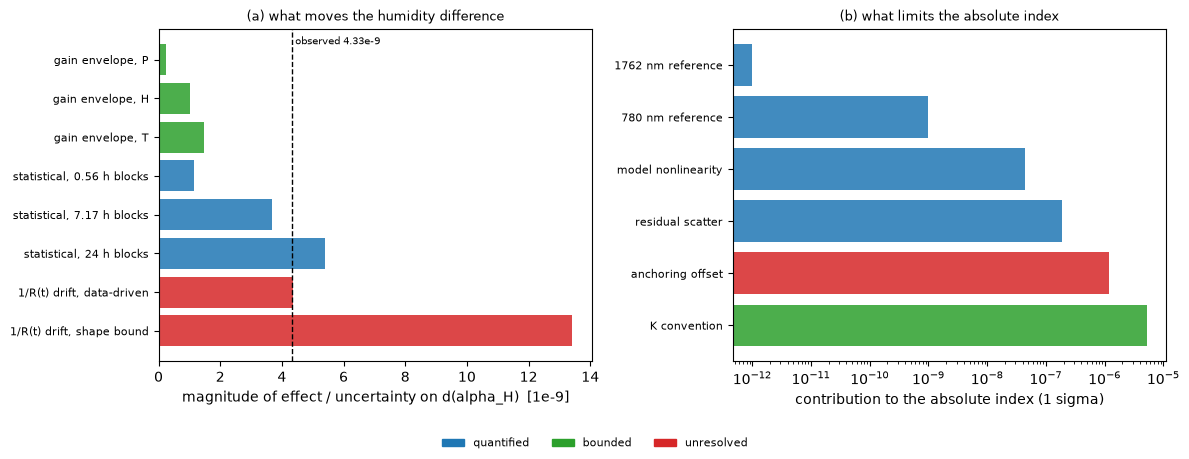

In [9]:
from matplotlib.patches import Patch

colmap = {'quantified': 'C0', 'bounded': 'C2', 'unresolved': 'C3'}
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

# --- (a) effect on d(alpha_H), in units of 1e-9
ax = axes[0]
items = [
    ('1/R(t) drift, shape bound',  INJ_SB * 1e9,   'unresolved'),
    ('1/R(t) drift, data-driven',  INJ_DD * 1e9,   'unresolved'),
    ('statistical, 24 h blocks',   U_STAT_240 * 1e9, 'quantified'),
    ('statistical, 7.17 h blocks', U_STAT_717 * 1e9, 'quantified'),
    ('statistical, 0.56 h blocks', U_STAT_056 * 1e9, 'quantified'),
    ('gain envelope, T',           ENV['T']['E'] * 1e9, 'bounded'),
    ('gain envelope, H',           ENV['H']['E'] * 1e9, 'bounded'),
    ('gain envelope, P',           ENV['P']['E'] * 1e9, 'bounded'),
]
y = np.arange(len(items))
ax.barh(y, [abs(i[1]) for i in items], color=[colmap[i[2]] for i in items], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels([i[0] for i in items], fontsize=8)
ax.axvline(D_H * 1e9, color='k', ls='--', lw=1.0)
ax.text(D_H * 1e9, len(items) - 0.4, f' observed {D_H*1e9:.2f}e-9', fontsize=7, va='top')
ax.set_xlabel('magnitude of effect / uncertainty on d(alpha_H)  [1e-9]')
ax.set_title('(a) what moves the humidity difference', fontsize=9)

# --- (b) absolute-index contributions, log scale
ax = axes[1]
ab = [
    ('K convention',      5.2e-6,  'bounded'),
    ('anchoring offset',  1.166e-6, 'unresolved'),
    ('residual scatter',  1.84e-7, 'quantified'),
    ('model nonlinearity', 4.4e-8, 'quantified'),
    ('780 nm reference',  1.0e-9,  'quantified'),
    ('1762 nm reference', 1e-12,   'quantified'),
]
y = np.arange(len(ab))
ax.barh(y, [abs(i[1]) for i in ab], color=[colmap[i[2]] for i in ab], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels([i[0] for i in ab], fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('contribution to the absolute index (1 sigma)')
ax.set_title('(b) what limits the absolute index', fontsize=9)

handles = [Patch(color=colmap[k], label=k) for k in ('quantified', 'bounded', 'unresolved')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, fontsize=8)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

## Export

Writes evidence_grading.json (machine-readable), evidence_grading.md
(human-readable) and evidence_grading.png (figure).

In [10]:
def to_md(rows):
    out = []
    for r in rows:
        head = f"- **{r['source']}** - *{r['label']}*"
        if r.get('qualifier'):
            head += f" ({r['qualifier']})"
        out.append(head)
        out.append(f"  - magnitude: {r['magnitude']}")
        out.append(f"  - temporal: {r['temporal']}")
        out.append(f"  - evidence: {r['evidence']}")
        out.append(f"  - effect: {r['effect']}")
    return '\n'.join(out)

summary = dict(
    generated_by='11_evidence_grading.ipynb',
    provenance={k: v for k, v in (('nb10_1overR', s10), ('nb07_blocks', s07),
                                  ('nb00_stats', s_st), ('nb05_coverage', s_cov),
                                  ('nb09_envelope', s_env))},
    headline=dict(d_alpha_H=D_H, u_stat_sm=U_STAT_SM, u_stat_056=U_STAT_056,
                  u_stat_717=U_STAT_717, u_stat_240=U_STAT_240, u_syst_H=US_H, envelope_max_H=E_H,
                  drift_injection_e9=[INJ_DD * 1e9, INJ_SB * 1e9], corr_T_t=CORR_TT),
    gate=gate,
    outputs=dict(A=rowsA, B=rowsB, C=rowsC),
)
with open('evidence_grading.json', 'w') as fh:
    json.dump(summary, fh, indent=1)

md_txt = ['# Evidence grading for the NS10657 measurement-chain budget', '',
          'Generated by 11_evidence_grading.ipynb.',
          '', 'Artifact provenance: ' + json.dumps(summary['provenance']),
          '', '## Output A - absolute refractive index', to_md(rowsA),
          '', '## Output B - environmental coefficients and the Mathar difference', to_md(rowsB),
          '', '## Output C - refractivity change and slow phase compensation', to_md(rowsC),
          '', '## §4 gate',
          f"- Q1: {gate['Q1']['answer']}",
          f"- Q2: {gate['Q2']['answer']}",
          f"- Verdict: {gate['verdict']}",
          f"- Provisional because: {gate['provisional_because']}",
          f"- Not claimed: {gate['not_claimed']}"]
with open('evidence_grading.md', 'w') as fh:
    fh.write('\n'.join(md_txt))

fig.savefig('evidence_grading.png', dpi=200, bbox_inches='tight')
print('wrote evidence_grading.json / evidence_grading.md / evidence_grading.png')

wrote evidence_grading.json / evidence_grading.md / evidence_grading.png


## Optional - re-derive the step-1 gate

Set RECOMPUTE_BASELINE = True to recompute the unperturbed full-resolution
d(alpha_H) from the raw data as an entry check. It is off by default so the
notebook runs in seconds from the frozen artifacts.

In [11]:
RECOMPUTE_BASELINE = False
if RECOMPUTE_BASELINE:
    import sys
    sys.path.insert(0, '.')
    from chain_propagation import Models, calibrate_K
    mo = Models('../models/nist/refractive_index.py', '../models/mathar/Mathar2007.py')
    d = pd.read_csv('../../data/processed/full_data.csv')
    d['time'] = pd.to_datetime(d['time'], utc=True)
    d = d.sort_values('time').reset_index(drop=True)
    Td, Hd, Pd = d.temperature.values, d.humidity.values, d.pressure.values
    Rd, yd = d.counts_ratio.values, d.n_1762.values
    Kd, n780d = calibrate_K(mo, Td, Hd, Pd, Rd, yd)
    Xd = np.column_stack([np.ones(len(d)), Td, Hd, Pd])
    a_data = np.linalg.lstsq(Xd, Kd * n780d / Rd, rcond=None)[0]
    a_math = np.linalg.lstsq(Xd, mo.mathar(1.762, Td, Pd, Hd), rcond=None)[0]
    dH = 1e9 * (a_data[2] - a_math[2])
    print(f'N = {len(d)}, d(alpha_H) = {dH:+.4f}e-9 (archived {D_H*1e9:+.4f}e-9)')
    assert abs(dH - D_H * 1e9) < 0.01, 'step-1 gate failed'
else:
    print('RECOMPUTE_BASELINE = False; using the archived gate value '
          f'{D_H*1e9:+.4f}e-9 (reproduced in nb 08/10 at full resolution).')

RECOMPUTE_BASELINE = False; using the archived gate value +4.3334e-9 (reproduced in nb 08/10 at full resolution).
